In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import kagglehub

In [2]:
print("Downloading dataset...")
path = kagglehub.dataset_download("raagbhutani/kidneystone")
print("Dataset downloaded at:", path)

100%|██████████| 611M/611M [01:19<00:00, 8.10MB/s] 

Extracting files...


Dataset downloaded at: /Users/krishasheta/.cache/kagglehub/datasets/raagbhutani/kidneystone/versions/1


In [4]:
def find_image_folder(base_path):
    for root, dirs, files in os.walk(base_path):
        image_files = [f for f in files if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if len(image_files) > 0:
            return os.path.dirname(root)
    return base_path

DATA_DIR = find_image_folder("CT_SCAN")

print("Using DATA_DIR:", DATA_DIR)

Using DATA_DIR: CT_SCAN


In [5]:
CATEGORIES = [
    folder for folder in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, folder))
]

print("Detected Categories:", CATEGORIES)

IMG_SIZE = 128
data = []

Detected Categories: ['Kidney_stone', 'Normal']


In [6]:
for category in CATEGORIES:
    path_cat = os.path.join(DATA_DIR, category)
    class_num = CATEGORIES.index(category)

    print(f"Loading {category}...")

    for img in os.listdir(path_cat):
        try:
            img_path = os.path.join(path_cat, img)
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img_array is None:
                continue

            resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            data.append([resized_array, class_num])

        except:
            continue

print("Total Images Loaded:", len(data))

Loading Kidney_stone...
Loading Normal...
Total Images Loaded: 1609


In [17]:
random.shuffle(data)

X, y = [], []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
y = np.array(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", len(X_train), " Test:", len(X_test))




Train: 1287  Test: 322


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [20]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPool2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPool2D(2,2),

    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,391,873 (28.20 MB)

 Trainable params: 7,391,873 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 232ms/step - accuracy: 0.5128 - loss: 0.8224 - val_accuracy: 0.5280 - val_loss: 0.6897
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 219ms/step - accuracy: 0.5835 - loss: 0.6800 - val_accuracy: 0.6584 - val_loss: 0.6433
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 290ms/step - accuracy: 0.6744 - loss: 0.6126 - val_accuracy: 0.7174 - val_loss: 0.5608
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 343ms/step - accuracy: 0.7731 - loss: 0.4823 - val_accuracy: 0.7826 - val_loss: 0.4697
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 278ms/step - accuracy: 0.8524 - loss: 0.3395 - val_accuracy: 0.7981 - val_loss: 0.4146
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - accuracy: 0.9013 - loss: 0.2437 - val_accuracy: 0.8509 - val_loss: 0.3374
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 217ms/step - accuracy: 0.9542 - loss: 0.1521 - val_accuracy: 0.8882 - val_loss: 0.2747
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 217ms/step - accuracy: 0.9611 - loss: 0.1089 - val_accuracy

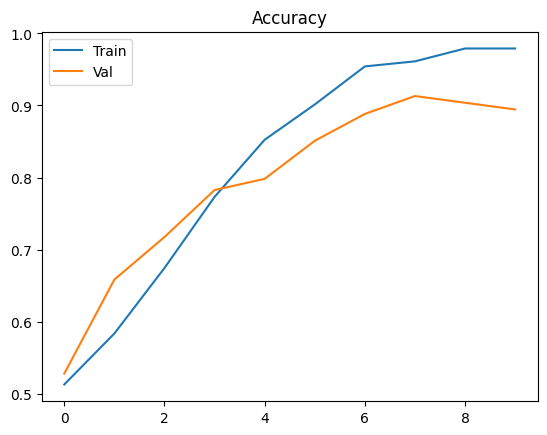

In [23]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])
plt.show()


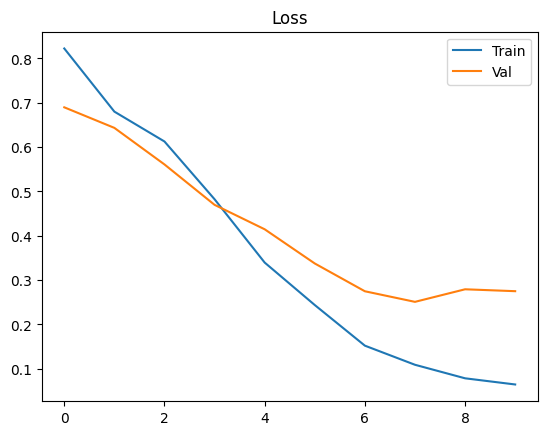

In [24]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Val"])
plt.show()

Training Accuracy: 0.9984
Test Accuracy: 0.8944
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.82      0.88       152
           1       0.86      0.96      0.91       170

    accuracy                           0.89       322
   macro avg       0.90      0.89      0.89       322
weighted avg       0.90      0.89      0.89       322

Confusion Matrix:
 [[125  27]
 [  7 163]]


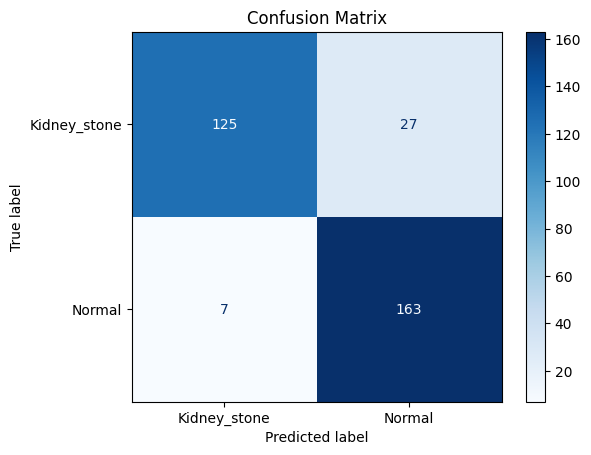

In [36]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = (model.predict(X_test) > 0.5).astype("int32").ravel()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CATEGORIES)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [26]:
model.save("kidney_stone_model.h5")
print("Model saved!")

Model saved!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


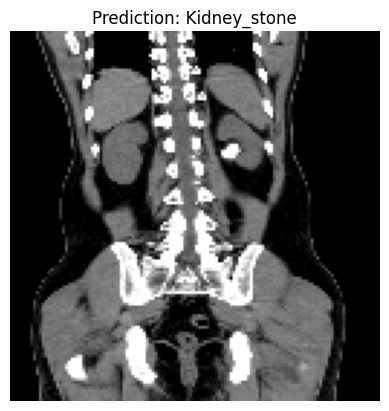

In [32]:
sample = X_test[10].reshape(1, IMG_SIZE, IMG_SIZE, 1)
prediction = model.predict(sample)

label = CATEGORIES[int(prediction[0][0] > 0.5)]

plt.imshow(X_test[10].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title("Prediction: " + label)
plt.axis('off')
plt.show()